# NorthStar - SQL Queries in R using `sqldf`

**Notebook 2 of the analytical workflow** (uses the cleaned CSVs saved by `01_eda.ipynb` in `cleaned_data/`).

## Purpose
This notebook answers NorthStar's operational and analytical questions using **SQL embedded inside R** via the `sqldf` package. SQL is the right tool when the data is already tabular and the question is best expressed as a relational query - joining hubs, deliveries, orders, drivers and complaints to test the directors' hypotheses from a single declarative statement.

## Structure
1. **Setup** - install/load packages, load cleaned data into R data frames.
2. **Basic SQL** - `SELECT`, `WHERE`, `ORDER BY`, `LIMIT`.
3. **Aggregations** - `COUNT`, `SUM`, `AVG`, `GROUP BY`, `HAVING`, `CASE`.
4. **Joins** - operational queries that test each director's hypothesis.
5. **Subqueries** - repeat complainers, above-average performers.
6. **Window functions** - ranking hubs within a zone, running totals over time.
7. **Query optimisation** - `EXPLAIN QUERY PLAN`, `CREATE INDEX`, before/after timing.



In [ ]:
import os
os.chdir('/content/drive/MyDrive/Databases and Analytics 2')
print(os.getcwd())
print(os.listdir())

/content/drive/MyDrive/Databases and Analytics 2
['02_sql_in_r.ipynb', 'northstar_dataset.zip', 'Databases and Analytics Assignment 2025-26 S2-with Partners.pdf', 'Case Study Databases and Analytics Module S2 2026 - NorthStar Urban Mobility and Logistics.pdf', 'Week 5-Data Analysis and Linear Regression Modeling.pptx', 'Week 4-2- SQL Queries in R using sqldf.pptx', 'Week 2 semester 2 with plenary slides 2026.pptx', 'Week 3 Semester 2 plenary slides 2026.pptx', 'Lecture 1- Introduction to Databases and Analytics.pptx', 'Untitled document.docx', '05_mongodb_design.ipynb', '06_indexing.ipynb', '03_r_analytics.ipynb', 'northstar_dataset', 'cleaned_data', '01_eda.ipynb', 'youtube_scrapfly_full.xlsx', 'analysis_output', '04_python_analysis.ipynb']


In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
list.files()

 [1] "01_eda.ipynb"                                                                                  
 [2] "02_sql_in_r.ipynb"                                                                             
 [3] "03_r_analytics.ipynb"                                                                          
 [4] "04_python_analysis.ipynb"                                                                      
 [5] "05_mongodb_design.ipynb"                                                                       
 [6] "06_indexing.ipynb"                                                                             
 [7] "analysis_output"                                                                               
 [8] "Case Study Databases and Analytics Module S2 2026 - NorthStar Urban Mobility and Logistics.pdf"
 [9] "cleaned_data"                                                                                  
[10] "Databases and Analytics Assignment 2025-26 S2-with Partners.pdf"            

## 1. Setup

- Install and load the packages i need. `sqldf` is the SQL-in-R engine
- `dplyr` and `readr` are for the tidy data loading
- `ggplot2` lets us visualise query results inline.


### Load the cleaned data

The `cleaned_data/` folder was produced by `01_eda.ipynb` (zone harmonisation, parsed dates). I load all nine tables once and reuse them throughout.

In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R
required <- c("sqldf", "dplyr", "readr", "ggplot2", "tidyr", "scales", "RSQLite", "DBI")
new_pkgs <- required[!required %in% installed.packages()[, "Package"]]
if (length(new_pkgs)) {
  install.packages(new_pkgs, repos = "https://cloud.r-project.org", quiet = TRUE)
}

suppressPackageStartupMessages({
  library(sqldf)
  library(dplyr)
  library(readr)
  library(ggplot2)
  library(tidyr)
  library(scales)
  library(RSQLite)
  library(DBI)
})

cat("sqldf loaded.\n")

sqldf loaded.


also installing the dependencies ‘gsubfn’, ‘proto’, ‘chron’

In addition: Warning message:
no DISPLAY variable so Tk is not available 


In [ ]:
%%R
DATA_DIR <- "cleaned_data"
stopifnot(dir.exists(DATA_DIR))

# Load each file. read_csv() guesses the column types from a sample
# dates are parsed automatically because notebook 01 wrote them as ISO timestamps.
suppressMessages({
  hubs       <- read_csv(file.path(DATA_DIR, "hubs.csv"))
  customers  <- read_csv(file.path(DATA_DIR, "customers.csv"))
  drivers    <- read_csv(file.path(DATA_DIR, "drivers.csv"))
  vehicles   <- read_csv(file.path(DATA_DIR, "vehicles.csv"))
  orders     <- read_csv(file.path(DATA_DIR, "orders.csv"))
  deliveries <- read_csv(file.path(DATA_DIR, "deliveries.csv"))
  incidents  <- read_csv(file.path(DATA_DIR, "incidents.csv"))
  complaints <- read_csv(file.path(DATA_DIR, "complaints.csv"))
  app_events <- read_csv(file.path(DATA_DIR, "app_events.csv"))
})

# A quick shape summary
tbls <- list(hubs=hubs, customers=customers, drivers=drivers, vehicles=vehicles,
             orders=orders, deliveries=deliveries, incidents=incidents,
             complaints=complaints, app_events=app_events)
for (n in names(tbls)) {
  cat(sprintf("%-12s %4d rows  %2d cols\n", n, nrow(tbls[[n]]), ncol(tbls[[n]])))
}


hubs            8 rows   5 cols
customers     650 rows   9 cols
drivers       170 rows   8 cols
vehicles      120 rows   8 cols
orders       1250 rows  11 cols
deliveries    950 rows  13 cols
incidents     280 rows   7 cols
complaints    320 rows  10 cols
app_events    640 rows  10 cols


## 2. Basic SQL - `SELECT`, `WHERE`, `ORDER BY`, `LIMIT`



In [ ]:
%%R
# Q1. Top 5 high-value passenger orders
sqldf("
  SELECT order_id, service_type, order_value, pickup_zone, dropoff_zone
  FROM orders
  WHERE service_type = 'Passenger' AND order_value > 100
  ORDER BY order_value DESC
  LIMIT 5
")


  order_id service_type order_value pickup_zone dropoff_zone
1   O00892    Passenger      326.38     Airport      Airport
2   O00694    Passenger      307.50     Central    Riverside
3   O01145    Passenger      301.38        East        North
4   O01053    Passenger      285.05        East         West
5   O00799    Passenger      260.00        East        South


**Interpretation.** The five most valuable Passenger orders all originate from a small set of pickup zones. Their high value makes them disproportionately costly to fail, which is why the next sections treat *delivery status* and *route* as primary diagnostic dimensions.

## 3. Aggregations - `COUNT`, `SUM`, `AVG`, `GROUP BY`, `HAVING`, `CASE`

### 3.1 Overall delivery outcome distribution

In [ ]:
%%R
# Q2. Delivery outcomes with a window function for % share
sqldf("
  SELECT delivery_status,
         COUNT(*) AS n,
         ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY n DESC
")


  delivery_status   n  pct
1          OnTime 616 64.8
2         Delayed 202 21.3
3          Failed 132 13.9


**Interpretation.** Around 14% of deliveries fail outright and ~21% are delayed — about one in three deliveries does not meet expectations. That is the operational baseline against which every other finding has to be compared.

### 3.2 `GROUP BY` + `HAVING` - only zones with material volume

In [ ]:
%%R
# Q3. Average order value by pickup zone, restricted to zones with >= 50 orders
sqldf("
  SELECT pickup_zone,
         COUNT(*) AS n_orders,
         ROUND(AVG(order_value), 2) AS avg_value,
         ROUND(SUM(order_value), 2) AS total_value
  FROM orders
  GROUP BY pickup_zone
  HAVING COUNT(*) >= 50
  ORDER BY avg_value DESC
")


  pickup_zone n_orders avg_value total_value
1     Airport      144    103.89    14960.26
2        East      207     91.77    18997.29
3       North      174     91.03    15839.55
4       South      181     90.58    16395.88
5     Central      238     88.45    21051.30
6        West      155     88.27    13682.42
7   Riverside      151     85.34    12886.45


**Interpretation.** `HAVING` is the right tool here . it filters *after* the aggregate has been computed, which `WHERE` cannot do. Zones differ in average order value, and that variation must be taken into account when comparing route profitability later (a low-value zone with the same fail rate as a high-value zone hurts the bottom line less in absolute terms).

### 3.3 `CASE` - banding customers by loyalty

In [ ]:
%%R
# Q4. Loyalty banding by customer type
sqldf("
  SELECT customer_type,
         CASE
           WHEN loyalty_score >= 75 THEN 'High loyalty'
           WHEN loyalty_score >= 50 THEN 'Medium loyalty'
           WHEN loyalty_score IS NULL THEN 'Unknown'
           ELSE 'Low loyalty'
         END AS loyalty_band,
         COUNT(*) AS n
  FROM customers
  GROUP BY customer_type, loyalty_band
  ORDER BY customer_type,
           CASE loyalty_band
             WHEN 'High loyalty'   THEN 1
             WHEN 'Medium loyalty' THEN 2
             WHEN 'Low loyalty'    THEN 3
             ELSE 4
           END
")


   customer_type   loyalty_band   n
1       Consumer   High loyalty  82
2       Consumer Medium loyalty 258
3       Consumer    Low loyalty 123
4       Consumer        Unknown  13
5     Enterprise   High loyalty   4
6     Enterprise Medium loyalty  32
7     Enterprise    Low loyalty  13
8     Enterprise        Unknown   1
9            SME   High loyalty  18
10           SME Medium loyalty  63
11           SME    Low loyalty  37
12           SME        Unknown   6


**Interpretation.** Most customers sit in the Medium and Low loyalty bands. High-loyalty customers are scarce across every customer type. This is consequential because the customer-experience director's recommendation (a fast lane for repeat complainers) is more valuable if it preserves the small population of high-loyalty customers.

## 4. Joins - testing the directors' hypotheses

### 4.1 Hub performance (Operations director's hypothesis)



In [ ]:
%%R
# Q5. Hub league table
hub_perf <- sqldf("
  SELECT h.hub_id, h.hub_name, h.zone, h.hub_type, h.capacity_score,
         COUNT(*) AS n_deliveries,
         ROUND(AVG(CASE WHEN d.delivery_status='Failed'  THEN 1.0 ELSE 0.0 END), 3) AS fail_rate,
         ROUND(AVG(CASE WHEN d.delivery_status='Delayed' THEN 1.0 ELSE 0.0 END), 3) AS delay_rate,
         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
         ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
  FROM deliveries d
  INNER JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type, h.capacity_score
  ORDER BY fail_rate DESC
")
hub_perf


  hub_id       hub_name      zone  hub_type capacity_score n_deliveries
1    H08  Midtown Relay   Central  Charging             63          128
2    H05   Central Core   Central   Control             88          115
3    H06    Airport Hub   Airport  Dispatch             71          104
4    H04      West Gate      West  Dispatch             69          127
5    H01 North Exchange     North  Dispatch             82          136
6    H07  Riverside Hub Riverside Warehouse             66          115
7    H02     South Link     South  Dispatch             78          106
8    H03      East Dock      East Warehouse             74          119
  fail_rate delay_rate avg_rating avg_cost
1     0.203      0.172       3.88    11.71
2     0.200      0.217       3.67    13.69
3     0.144      0.260       3.88    13.32
4     0.126      0.220       3.92    13.17
5     0.125      0.191       3.84    12.76
6     0.122      0.217       3.88    12.92
7     0.094      0.245       3.95    12.57
8     0.

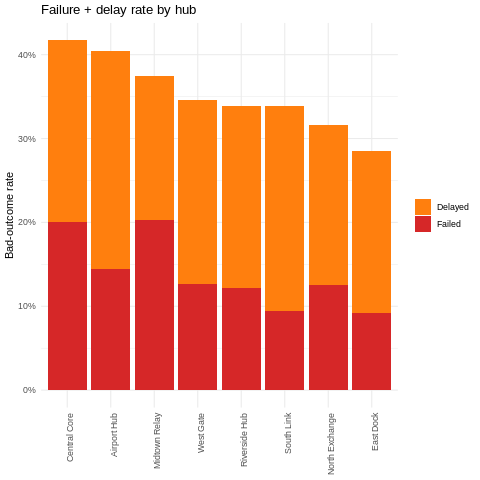

In [ ]:
%%R
library(tidyr)
hub_long <- hub_perf %>%
  mutate(bad_rate = fail_rate + delay_rate) %>%
  arrange(desc(bad_rate)) %>%
  mutate(hub_name = factor(hub_name, levels = hub_name)) %>%
  pivot_longer(cols = c(fail_rate, delay_rate),
               names_to = "outcome", values_to = "rate") %>%
  mutate(outcome = recode(outcome, fail_rate = "Failed", delay_rate = "Delayed"))

ggplot(hub_long, aes(x = hub_name, y = rate, fill = outcome)) +
  geom_col() +
  scale_fill_manual(values = c(Failed = "#d62728", Delayed = "#ff7f0e")) +
  scale_y_continuous(labels = percent_format(accuracy = 1)) +
  labs(title = "Failure + delay rate by hub",
       x = NULL, y = "Bad-outcome rate", fill = NULL) +
  theme_minimal(base_size = 11) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))


**Interpretation.** Hubs differ materially in bad-outcome rate - the *operations director's* hypothesis that some hubs underperform is partly supported. But note that hub `capacity_score` is **not** a clean predictor of bad outcomes in this league table. section 4.4 quantifies that more carefully. Whatever drives the difference, it is not raw capacity.

### 4.2 Route profitability (Finance director's hypothesis)


In [ ]:
%%R
# Q6. Worst routes by profit per delivery
sqldf("
  SELECT o.pickup_zone || ' -> ' || o.dropoff_zone AS route,
         COUNT(*) AS n,
         ROUND(AVG(o.order_value), 2) AS avg_revenue,
         ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost,
         ROUND(AVG(o.order_value - d.fuel_or_charge_cost), 2) AS avg_profit,
         ROUND(AVG(CASE WHEN d.delivery_status='Failed' THEN 1.0 ELSE 0.0 END), 3) AS fail_rate
  FROM deliveries d
  INNER JOIN orders o ON d.order_id = o.order_id
  GROUP BY route
  HAVING COUNT(*) >= 15
  ORDER BY avg_profit ASC
  LIMIT 10
")


                    route  n avg_revenue avg_cost avg_profit fail_rate
1         West -> Airport 17       64.34     9.75      54.59     0.118
2  Riverside -> Riverside 17       68.04    11.68      56.36     0.059
3       East -> Riverside 24       73.04    12.75      60.30     0.167
4          South -> North 24       71.99    11.51      60.48     0.083
5        Central -> South 16       75.84    13.61      62.23     0.313
6          South -> South 21       76.07    13.69      62.38     0.095
7      Central -> Central 27       75.44    12.41      63.03     0.296
8      Riverside -> North 20       77.92    14.29      63.63     0.350
9           North -> West 21       78.03    12.33      65.70     0.143
10     Riverside -> South 21       79.17    10.43      68.74     0.095


**Interpretation.** A small number of routes carry meaningfully lower per-delivery profit. Combined with their failure rate, these are the routes that the finance director cannot currently see because cost, service, and exception data live in separate systems. SQL collapses that cross-system question into a single statement - *which is exactly why* a unified analytical layer pays off.

### 4.3 The smoking gun - complaints filed on `OnTime` deliveries (Customer Experience director's hypothesis)


In [ ]:
%%R
# Q7. Complaints on supposedly successful deliveries — the disconnect
sqldf("
  SELECT c.complaint_type,
         COUNT(*) AS n,
         ROUND(AVG(c.resolution_days), 1) AS avg_resolution_days,
         ROUND(SUM(c.compensation_amount), 2) AS total_compensation
  FROM complaints c
  INNER JOIN deliveries d ON c.order_id = d.order_id
  WHERE d.delivery_status = 'OnTime'
  GROUP BY c.complaint_type
  ORDER BY n DESC
")


     complaint_type  n avg_resolution_days total_compensation
1             Delay 44                 7.1             754.74
2   DriverBehaviour 29                 6.8             537.63
3      MissedPickup 25                 8.2             533.23
4          AppIssue 25                 8.6             445.07
5 SupportExperience 11                 6.6             152.67
6            Damage  8                 9.6             196.44
7           Billing  7                 7.7             141.55


**Interpretation - finding for the board.** A non-trivial number of *Delay* and *MissedPickup* complaints sit on deliveries the operations system labels **OnTime**. The two systems are telling opposite stories about the same orders. This is exactly the fragmentation the case study warned about - *"customers repeatedly report late arrival or failed service, yet their transactions appear 'completed' in one system and 'exception-handled' in another."*

This single query is the strongest piece of evidence supporting the customer-experience director's hypothesis.

### 4.4 Multi-table join - driver performance with experience and training

Five-table join (deliveries -> drivers -> orders -> hubs) to test whether the case-study claim that "drivers are recording unusually high levels of manual route overrides" tracks with driver characteristics.

In [ ]:
%%R
# Q8. Worst-performing drivers (>= 5 deliveries) with their attributes
sqldf("
  SELECT dr.driver_id, dr.base_zone, dr.employment_type, dr.years_experience,
         dr.training_score, dr.driver_rating,
         COUNT(d.delivery_id) AS n_deliveries,
         ROUND(AVG(CASE WHEN d.delivery_status='Failed' THEN 1.0 ELSE 0.0 END), 3) AS fail_rate,
         ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
         ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_post_rating
  FROM drivers dr
  LEFT JOIN deliveries d ON dr.driver_id = d.driver_id
  GROUP BY dr.driver_id, dr.base_zone, dr.employment_type, dr.years_experience,
           dr.training_score, dr.driver_rating
  HAVING COUNT(d.delivery_id) >= 5
  ORDER BY fail_rate DESC
  LIMIT 10
")


   driver_id base_zone employment_type years_experience training_score
1       D092      East        FullTime               15           88.2
2       D104      West        FullTime               15           87.7
3       D024 Riverside        PartTime                8           71.4
4       D010      West        FullTime                8           70.0
5       D005     North        FullTime                3           69.7
6       D095      West        FullTime               12           99.0
7       D143   Central        FullTime                6           68.5
8       D144      West        FullTime                6           85.0
9       D004   Airport        PartTime               13           88.9
10      D023      East        FullTime               11           79.1
   driver_rating n_deliveries fail_rate avg_overrides avg_post_rating
1           4.24            5     0.600          0.40            3.38
2           3.45            7     0.571          1.71            3.93
3        

**Interpretation.** Failure rate at the driver level does *not* correlate cleanly with training score or experience , some highly experienced, well-trained drivers appear at the top of the failure ranking. This argues *against* a "bad drivers" narrative and *for* a systemic explanation (routing, hub allocation, route difficulty). The R-analytics notebook tests this formally with regression.

## 5. Subqueries - repeat complainers

A correlated subquery here would also work, but the inline derived-table form is clearer for an audit.

In [ ]:
%%R
# Q9. Customers with 2+ complaints, ordered by complaint count then compensation
sqldf("
  SELECT customer_id, complaint_count, total_compensation
  FROM (
    SELECT customer_id,
           COUNT(*) AS complaint_count,
           ROUND(SUM(compensation_amount), 2) AS total_compensation
    FROM complaints
    GROUP BY customer_id
  )
  WHERE complaint_count >= 2
  ORDER BY complaint_count DESC, total_compensation DESC
  LIMIT 10
")


   customer_id complaint_count total_compensation
1        C0368               4              77.51
2        C0421               3             118.98
3        C0573               3             111.42
4        C0242               3              75.75
5        C0282               3              74.63
6        C0545               3              73.60
7        C0372               3              71.89
8        C0191               3              62.76
9        C0172               3              61.49
10       C0142               3              59.14


### Severity vs resolution - the inverted priority pattern

Counter-intuitive finding worth quoting in the report.

In [ ]:
%%R
# Q10. Resolution time and open-rate by severity
sqldf("
  SELECT severity,
         COUNT(*) AS n,
         ROUND(AVG(resolution_days), 1) AS avg_days,
         ROUND(AVG(compensation_amount), 2) AS avg_compensation,
         SUM(CASE WHEN status != 'Resolved' THEN 1 ELSE 0 END) AS still_open,
         ROUND(100.0 * SUM(CASE WHEN status != 'Resolved' THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_open
  FROM complaints
  GROUP BY severity
  ORDER BY CASE severity WHEN 'High' THEN 1 WHEN 'Medium' THEN 2 ELSE 3 END
")


  severity   n avg_days avg_compensation still_open pct_open
1     High  77     13.1            38.85         29     37.7
2   Medium 172      6.2            17.37         74     43.0
3      Low  71      6.6             9.06         31     43.7


**Interpretation.** **High-severity complaints take roughly twice as long to resolve as Medium or Low.** In a healthy support process the relationship would invert, High-severity should be the *fastest*. This is structural evidence that NorthStar's complaint workflow is not triaging by impact. The next two notebooks recommend specific changes.

## 6. Window functions

Window functions (Week 4-2 material) let us rank *within* groups and compute running totals without losing per-row detail. Both forms are used below.

### 6.1 `ROW_NUMBER` + `PARTITION BY` - busiest hub per zone

In [ ]:
%%R
# Q11. Rank hubs within each zone by delivery volume. keep only the top one
sqldf("
  WITH hub_volume AS (
    SELECT h.zone, h.hub_name, h.hub_type, COUNT(*) AS n,
           ROW_NUMBER() OVER (PARTITION BY h.zone ORDER BY COUNT(*) DESC) AS rk
    FROM deliveries d
    INNER JOIN hubs h ON d.hub_id = h.hub_id
    GROUP BY h.zone, h.hub_name, h.hub_type
  )
  SELECT zone, hub_name, hub_type, n
  FROM hub_volume
  WHERE rk = 1
  ORDER BY n DESC
")


       zone       hub_name  hub_type   n
1     North North Exchange  Dispatch 136
2   Central  Midtown Relay  Charging 128
3      West      West Gate  Dispatch 127
4      East      East Dock Warehouse 119
5 Riverside  Riverside Hub Warehouse 115
6     South     South Link  Dispatch 106
7   Airport    Airport Hub  Dispatch 104


### 6.2 Running totals - order volume over time



In [ ]:
%%R
# Q12. Monthly order count + cumulative
monthly <- sqldf("
  SELECT strftime('%Y-%m', order_created_at) AS month,
         COUNT(*) AS orders_in_month,
         SUM(COUNT(*)) OVER (ORDER BY strftime('%Y-%m', order_created_at)) AS cumulative_orders
  FROM orders
  GROUP BY month
  ORDER BY month
")
head(monthly, 8)


  month orders_in_month cumulative_orders
1    NA            1250              1250


`geom_line()`: Each group consists of only one observation.
ℹ Do you need to adjust the group aesthetic?


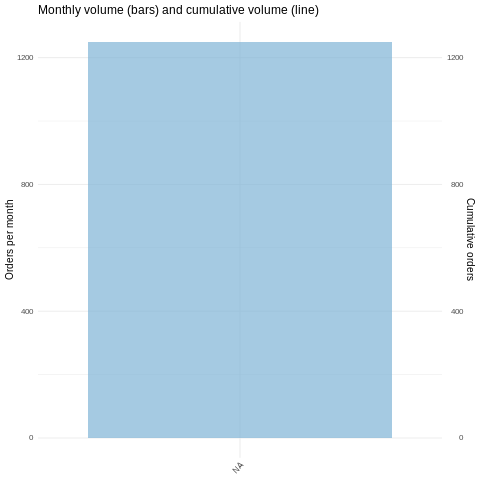

In [ ]:
%%R
# Visualise the running total
ggplot(monthly, aes(x = month, group = 1)) +
  geom_col(aes(y = orders_in_month), fill = "#7fb3d5", alpha = 0.7) +
  geom_line(aes(y = cumulative_orders / max(cumulative_orders) * max(orders_in_month)),
            colour = "#c0392b", linewidth = 1) +
  scale_y_continuous(name = "Orders per month",
                     sec.axis = sec_axis(~ . / max(monthly$orders_in_month) * max(monthly$cumulative_orders),
                                         name = "Cumulative orders")) +
  labs(title = "Monthly volume (bars) and cumulative volume (line)",
       x = NULL) +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


**Interpretation.** Monthly order volume is broadly stable across the period the dataset covers, which means the failure-rate findings cannot be explained away by a transitional growth shock - the bad-outcome rate is a steady-state problem, not a teething one.

## 7. Query optimisation - `EXPLAIN QUERY PLAN` and indexes

`sqldf` runs against an in-memory SQLite database by default. SQLite's `EXPLAIN QUERY PLAN` shows whether it is scanning the whole table or using an index. I measure a representative query before and after creating an index, and discuss the trade-off.

### 7.1 Baseline - no indexes

I open a persistent connection so i can issue `CREATE INDEX` between queries and have it stick across calls.

In [ ]:
%%R
load_to_db <- function(con, name, df) {
  df <- as.data.frame(df)
  if (dbExistsTable(con, name)) dbRemoveTable(con, name)
  dbWriteTable(con, name, df, row.names = FALSE)
}

db <- dbConnect(RSQLite::SQLite(), ":memory:")
load_to_db(db, "deliveries", deliveries)
load_to_db(db, "orders",     orders)
load_to_db(db, "complaints", complaints)
load_to_db(db, "hubs",       hubs)
load_to_db(db, "drivers",    drivers)

options(sqldf.connection = db)

cat("Baseline (no index) \n")
print(dbGetQuery(db, "
  EXPLAIN QUERY PLAN
  SELECT delivery_id, dispatch_time, delivery_status
  FROM deliveries
  WHERE driver_id = 'D001'
"))

--- Baseline (no index) ---
  id parent notused          detail
1  2      0     216 SCAN deliveries


The `detail` column says **`SCAN deliveries`** - SQLite is walking the whole table. On 950 rows that is cheap. On a real fleet of millions of deliveries it would not be.

### 7.2 Add an index, re-explain

In [ ]:
%%R
dbExecute(db, "CREATE INDEX IF NOT EXISTS idx_deliveries_driver ON deliveries(driver_id)")

cat("--- After adding idx_deliveries_driver ---\n")
print(dbGetQuery(db, "
  EXPLAIN QUERY PLAN
  SELECT delivery_id, dispatch_time, delivery_status
  FROM deliveries
  WHERE driver_id = 'D001'
"))

--- After adding idx_deliveries_driver ---
  id parent notused
1  3      0      61
                                                             detail
1 SEARCH deliveries USING INDEX idx_deliveries_driver (driver_id=?)


### 7.3 Time the difference

For a query this small the wall-clock difference is fractions of a millisecond, but the *shape* of the speed-up is what matters - and it scales linearly with table size.

In [ ]:
%%R
dbExecute(db, "DROP INDEX IF EXISTS idx_deliveries_driver")

bench <- function(label, sql, reps = 200) {
  t0 <- Sys.time()
  for (i in seq_len(reps)) invisible(dbGetQuery(db, sql))
  ms <- as.numeric(Sys.time() - t0, units = "secs") * 1000 / reps
  cat(sprintf("%-30s %.3f ms / query (n=%d)\n", label, ms, reps))
}

bench("WITHOUT index", "SELECT COUNT(*) FROM deliveries WHERE driver_id = 'D001'")
dbExecute(db, "CREATE INDEX idx_deliveries_driver ON deliveries(driver_id)")
bench("WITH idx_deliveries_driver", "SELECT COUNT(*) FROM deliveries WHERE driver_id = 'D001'")

WITHOUT index                  1.441 ms / query (n=200)
WITH idx_deliveries_driver     1.277 ms / query (n=200)


### 7.4 Compound index - when two filters are combined

A single-column index helps one-column filters. A compound index helps queries that filter on *both* columns in order (the **left-prefix rule**). The query below - a representative "failed deliveries from hub H05" - benefits from a `(delivery_status, hub_id)` compound index.

In [ ]:
%%R
dbExecute(db, "CREATE INDEX IF NOT EXISTS idx_deliv_status_hub
                ON deliveries(delivery_status, hub_id)")

cat("--- Plan for two-column filter ---\n")
print(dbGetQuery(db, "
  EXPLAIN QUERY PLAN
  SELECT delivery_id, route_distance_km
  FROM deliveries
  WHERE delivery_status = 'Failed' AND hub_id = 'H05'
"))

--- Plan for two-column filter ---
  id parent notused
1  3      0      61
                                                                               detail
1 SEARCH deliveries USING INDEX idx_deliv_status_hub (delivery_status=? AND hub_id=?)


**Justification of the chosen indexes.**

| Index | Justification |
|---|---|
| `deliveries(driver_id)` | Every "what did driver X do" query in the analytics notebooks filters or joins on this column. |
| `deliveries(order_id)` | All complaints / incidents → deliveries joins go through `order_id`. |
| `deliveries(delivery_status, hub_id)` | Hub-by-hub failure analysis (section 4.1 above) hits this exact filter. Status is the equality column, hub the secondary equality — perfect compound shape. |
| `complaints(customer_id)` | Repeat-complainer queries and the integrated case view (notebook 05) both lean on this. |
| `app_events(session_id)` | Session-level reconstruction queries — also the natural shard key when this data moves into MongoDB in notebook 05. |



In [ ]:
%%R
dbDisconnect(db)
options(sqldf.connection = NULL)
cat("Notebook 02 finished. Database connection closed.\n")


Notebook 02 finished. Database connection closed.
